In [9]:
# Step 1: Install packages
!pip install opencv-python-headless scikit-image pandas matplotlib scipy seaborn


Saving shared image (21).jpg to shared image (21).jpg
🎯 ADVANCED FRAGMENT ANALYZER
Testing multiple segmentation methods...

🔬 Testing SLIC method...
Creating slic superpixel segmentation with 800 segments...
Created 641 superpixel regions
Analyzing fragment sizes for each superpixel...
Processing segment 0/641
Processing segment 100/641
Processing segment 200/641
Processing segment 300/641
Processing segment 400/641
Processing segment 500/641
Processing segment 600/641
Creating colored size map...
✅ slic completed successfully


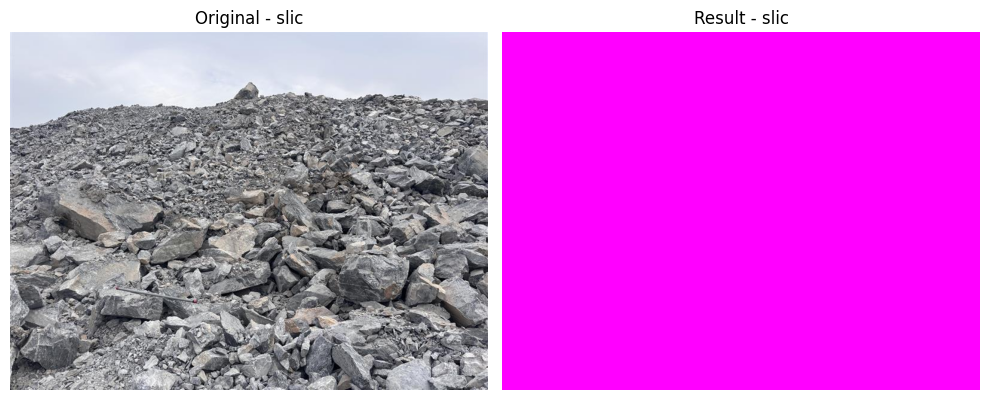


🔬 Testing FELZENSZWALB method...
Creating felzenszwalb superpixel segmentation with 800 segments...
Created 2215 superpixel regions
Analyzing fragment sizes for each superpixel...
Processing segment 0/2215
Processing segment 100/2215
Processing segment 200/2215
Processing segment 300/2215
Processing segment 400/2215
Processing segment 500/2215
Processing segment 600/2215
Processing segment 700/2215
Processing segment 800/2215
Processing segment 900/2215
Processing segment 1000/2215
Processing segment 1100/2215
Processing segment 1200/2215
Processing segment 1300/2215
Processing segment 1400/2215
Processing segment 1500/2215
Processing segment 1600/2215
Processing segment 1700/2215
Processing segment 1800/2215
Processing segment 1900/2215
Processing segment 2000/2215
Processing segment 2100/2215
Processing segment 2200/2215
Creating colored size map...
✅ felzenszwalb completed successfully


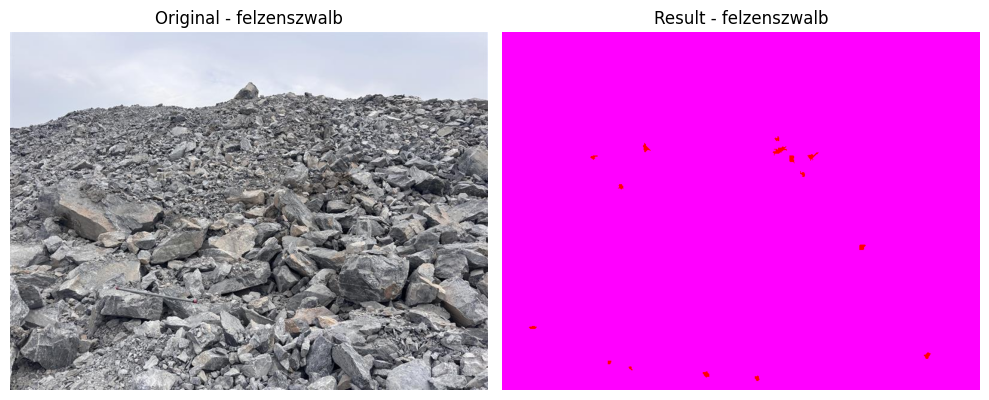


🔬 Testing QUICKSHIFT method...
Creating quickshift superpixel segmentation with 800 segments...
Created 2540 superpixel regions
Analyzing fragment sizes for each superpixel...
Processing segment 0/2540
Processing segment 100/2540
Processing segment 200/2540
Processing segment 300/2540
Processing segment 400/2540
Processing segment 500/2540
Processing segment 600/2540
Processing segment 700/2540
Processing segment 800/2540
Processing segment 900/2540
Processing segment 1000/2540
Processing segment 1100/2540
Processing segment 1200/2540
Processing segment 1300/2540
Processing segment 1400/2540
Processing segment 1500/2540
Processing segment 1600/2540
Processing segment 1700/2540
Processing segment 1800/2540
Processing segment 1900/2540
Processing segment 2000/2540
Processing segment 2100/2540
Processing segment 2200/2540
Processing segment 2300/2540
Processing segment 2400/2540
Processing segment 2500/2540
Creating colored size map...
✅ quickshift completed successfully


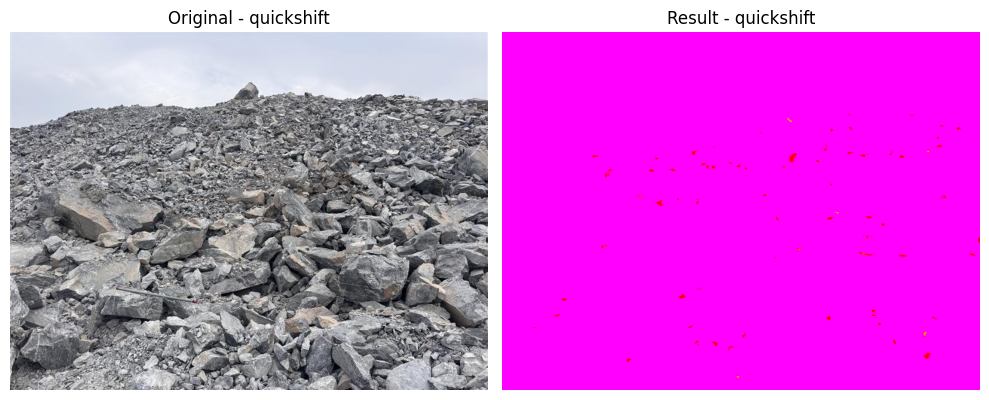

In [10]:
# Installation commands for Google Colab (run these first)
# !pip install opencv-python-headless scikit-image pandas matplotlib scipy seaborn
# !pip install segment-anything
# !pip install torch torchvision

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import measure, segmentation, filters, morphology, feature
from skimage.segmentation import slic, felzenszwalb, quickshift
import pandas as pd
import seaborn as sns
from scipy.ndimage import gaussian_filter, binary_fill_holes
import warnings
warnings.filterwarnings('ignore')

class ModernFragmentAnalyzer:
    def __init__(self, image_path, pixel_to_mm_ratio=1.0):
        """
        Modern fragment analyzer using advanced segmentation methods.

        Args:
            image_path: Path to the rock fragment image
            pixel_to_mm_ratio: Conversion factor from pixels to millimeters
        """
        self.image_path = image_path
        self.pixel_to_mm_ratio = pixel_to_mm_ratio
        self.original_image = None
        self.processed_image = None
        self.superpixels = None
        self.fragment_size_map = None
        self.colored_result = None

        # Enhanced color scheme for better visualization
        self.size_categories = {
            'Very Fine (< 5mm)': {'color': [255, 0, 255], 'range': (0, 5)},      # Magenta
            'Fine (5-10mm)': {'color': [255, 0, 0], 'range': (5, 10)},           # Red
            'Medium (10-20mm)': {'color': [255, 165, 0], 'range': (10, 20)},     # Orange
            'Coarse (20-40mm)': {'color': [255, 255, 0], 'range': (20, 40)},     # Yellow
            'Large (40-80mm)': {'color': [0, 255, 0], 'range': (40, 80)},        # Green
            'Very Large (> 80mm)': {'color': [0, 0, 255], 'range': (80, 1000)}   # Blue
        }

    def load_and_preprocess(self):
        """Enhanced preprocessing with multiple methods."""
        self.original_image = cv2.imread(self.image_path)
        if self.original_image is None:
            raise ValueError(f"Could not load image from {self.image_path}")

        # Convert to RGB for consistency
        self.original_image = cv2.cvtColor(self.original_image, cv2.COLOR_BGR2RGB)

        # Convert to grayscale
        gray = cv2.cvtColor(self.original_image, cv2.COLOR_RGB2GRAY)

        # Multi-stage preprocessing
        # 1. Noise reduction
        denoised = cv2.fastNlMeansDenoising(gray)

        # 2. Contrast enhancement
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(denoised)

        # 3. Edge-preserving smoothing
        self.processed_image = cv2.bilateralFilter(enhanced, 9, 75, 75)

        return self.processed_image

    def create_superpixel_segmentation(self, method='slic', n_segments=1000):
        """
        Create superpixel segmentation using modern methods.

        Args:
            method: 'slic', 'felzenszwalb', 'quickshift', or 'watershed'
            n_segments: Number of superpixel segments
        """
        if self.processed_image is None:
            self.load_and_preprocess()

        print(f"Creating {method} superpixel segmentation with {n_segments} segments...")

        if method == 'slic':
            # SLIC (Simple Linear Iterative Clustering) - best for regular, compact segments
            segments = slic(self.original_image, n_segments=n_segments, compactness=10,
                          sigma=1, start_label=1)

        elif method == 'felzenszwalb':
            # Felzenszwalb - good for natural boundaries
            segments = felzenszwalb(self.original_image, scale=100, sigma=0.5,
                                  min_size=50)

        elif method == 'quickshift':
            # Quickshift - good for varying densities
            segments = quickshift(self.original_image, kernel_size=3, max_dist=6,
                                ratio=0.5)

        elif method == 'watershed':
            # Watershed on gradient
            segments = self.watershed_segmentation()

        else:
            raise ValueError(f"Unknown method: {method}")

        self.superpixels = segments
        print(f"Created {len(np.unique(segments))} superpixel regions")

        return segments

    def watershed_segmentation(self):
        """Advanced watershed segmentation."""
        # Compute gradient
        gradient = morphology.gradient(self.processed_image, morphology.disk(2))

        # Local minima
        markers = morphology.local_minima(gradient)
        markers = measure.label(markers)

        # Watershed
        segments = morphology.watershed(gradient, markers)

        return segments

    def analyze_superpixel_texture(self, segment_id):
        """
        Analyze texture properties of a superpixel to estimate fragment size.

        Args:
            segment_id: ID of the superpixel segment
        """
        # Get mask for this segment
        mask = self.superpixels == segment_id

        if np.sum(mask) == 0:
            return 5  # Default small size

        # Extract region
        region_pixels = self.processed_image[mask]

        if len(region_pixels) < 10:
            return 5

        # Method 1: Statistical texture features
        mean_intensity = np.mean(region_pixels)
        std_intensity = np.std(region_pixels)

        # Method 2: Local Binary Pattern (simplified)
        lbp_variance = self.compute_lbp_variance(mask)

        # Method 3: Gradient-based texture
        gradient_strength = self.compute_gradient_texture(mask)

        # Method 4: Autocorrelation-based size
        autocorr_size = self.compute_autocorr_size(mask)

        # Method 5: Region shape analysis
        props = measure.regionprops(mask.astype(int))[0] if len(measure.regionprops(mask.astype(int))) > 0 else None

        shape_factor = 1.0
        if props:
            # Use area and perimeter to estimate characteristic size
            area = props.area
            perimeter = props.perimeter
            if perimeter > 0:
                compactness = 4 * np.pi * area / (perimeter ** 2)
                shape_factor = compactness

        # Combine features to estimate fragment size
        # Higher variance and gradient -> larger fragments
        # Higher LBP variance -> more texture -> larger fragments

        texture_score = (std_intensity * 0.3 +
                        lbp_variance * 0.2 +
                        gradient_strength * 0.3 +
                        autocorr_size * 0.2)

        # Map to reasonable size range
        estimated_size = np.clip(texture_score * shape_factor * 0.8, 2, 150)

        return estimated_size

    def compute_lbp_variance(self, mask):
        """Compute Local Binary Pattern variance for texture analysis."""
        try:
            # Get bounding box of the region
            coords = np.where(mask)
            if len(coords[0]) == 0:
                return 1.0

            min_row, max_row = np.min(coords[0]), np.max(coords[0])
            min_col, max_col = np.min(coords[1]), np.max(coords[1])

            # Extract region
            region = self.processed_image[min_row:max_row+1, min_col:max_col+1]
            region_mask = mask[min_row:max_row+1, min_col:max_col+1]

            if region.size < 9:
                return 1.0

            # Simplified LBP calculation
            lbp_values = []
            for i in range(1, region.shape[0]-1):
                for j in range(1, region.shape[1]-1):
                    if region_mask[i, j]:
                        center = region[i, j]
                        lbp = 0
                        for di in [-1, 0, 1]:
                            for dj in [-1, 0, 1]:
                                if di == 0 and dj == 0:
                                    continue
                                if region[i+di, j+dj] >= center:
                                    lbp += 1
                        lbp_values.append(lbp)

            return np.var(lbp_values) if len(lbp_values) > 0 else 1.0

        except:
            return 1.0

    def compute_gradient_texture(self, mask):
        """Compute gradient-based texture measure."""
        try:
            # Compute gradients
            grad_x = cv2.Sobel(self.processed_image, cv2.CV_64F, 1, 0, ksize=3)
            grad_y = cv2.Sobel(self.processed_image, cv2.CV_64F, 0, 1, ksize=3)
            gradient_mag = np.sqrt(grad_x**2 + grad_y**2)

            # Get gradient values in the region
            region_gradients = gradient_mag[mask]

            return np.mean(region_gradients) if len(region_gradients) > 0 else 1.0

        except:
            return 1.0

    def compute_autocorr_size(self, mask):
        """Estimate characteristic size using autocorrelation."""
        try:
            # Get bounding box
            coords = np.where(mask)
            if len(coords[0]) == 0:
                return 5

            min_row, max_row = np.min(coords[0]), np.max(coords[0])
            min_col, max_col = np.min(coords[1]), np.max(coords[1])

            # Characteristic size based on bounding box
            width = max_col - min_col + 1
            height = max_row - min_row + 1
            char_size = np.sqrt(width * height) * 0.3  # Factor for characteristic size

            return max(char_size, 5)

        except:
            return 5

    def estimate_fragment_sizes(self):
        """Estimate fragment size for each superpixel."""
        if self.superpixels is None:
            self.create_superpixel_segmentation()

        unique_segments = np.unique(self.superpixels)
        size_map = np.zeros_like(self.superpixels, dtype=np.float32)

        print("Analyzing fragment sizes for each superpixel...")

        for i, segment_id in enumerate(unique_segments):
            if i % 100 == 0:
                print(f"Processing segment {i}/{len(unique_segments)}")

            # Estimate size for this superpixel
            estimated_size = self.analyze_superpixel_texture(segment_id)

            # Convert to mm
            size_mm = estimated_size * self.pixel_to_mm_ratio

            # Fill the superpixel with estimated size
            mask = self.superpixels == segment_id
            size_map[mask] = size_mm

        # Apply smoothing
        size_map = gaussian_filter(size_map, sigma=0.5)

        self.fragment_size_map = size_map
        return size_map

    def create_colored_size_map(self):
        """Create colored map based on estimated fragment sizes."""
        if self.fragment_size_map is None:
            self.estimate_fragment_sizes()

        height, width = self.fragment_size_map.shape
        colored_map = np.zeros((height, width, 3), dtype=np.uint8)

        print("Creating colored size map...")

        # Color each pixel based on its estimated size
        for category, info in self.size_categories.items():
            min_size, max_size = info['range']
            color = info['color']

            # Create mask for this size category
            mask = (self.fragment_size_map >= min_size) & (self.fragment_size_map < max_size)
            colored_map[mask] = color

        self.colored_result = colored_map
        return colored_map

    def calculate_statistics(self):
        """Calculate comprehensive statistics."""
        if self.fragment_size_map is None:
            return None

        valid_sizes = self.fragment_size_map[self.fragment_size_map > 0]

        if len(valid_sizes) == 0:
            return None

        # Basic statistics
        stats = {
            'total_pixels': len(valid_sizes),
            'mean_size_mm': np.mean(valid_sizes),
            'median_size_mm': np.median(valid_sizes),
            'std_size_mm': np.std(valid_sizes),
            'min_size_mm': np.min(valid_sizes),
            'max_size_mm': np.max(valid_sizes)
        }

        # Size distribution
        distribution = {}
        for category, info in self.size_categories.items():
            min_size, max_size = info['range']
            mask = (valid_sizes >= min_size) & (valid_sizes < max_size)
            count = np.sum(mask)
            percentage = (count / len(valid_sizes)) * 100

            distribution[category] = {
                'count': count,
                'percentage': percentage
            }

        stats['distribution'] = distribution
        return stats, valid_sizes

    def visualize_results(self):
        """Create comprehensive visualizations."""
        if self.colored_result is None:
            self.create_colored_size_map()

        stats, valid_sizes = self.calculate_statistics()

        # Create figure
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))

        # 1. Original image
        axes[0, 0].imshow(self.original_image)
        axes[0, 0].set_title('Original Image', fontweight='bold', fontsize=12)
        axes[0, 0].axis('off')

        # 2. Superpixel segmentation
        axes[0, 1].imshow(segmentation.mark_boundaries(self.original_image, self.superpixels))
        axes[0, 1].set_title('Superpixel Segmentation', fontweight='bold', fontsize=12)
        axes[0, 1].axis('off')

        # 3. Size map (grayscale)
        im = axes[0, 2].imshow(self.fragment_size_map, cmap='viridis')
        axes[0, 2].set_title('Fragment Size Map (mm)', fontweight='bold', fontsize=12)
        axes[0, 2].axis('off')
        plt.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)

        # 4. MAIN RESULT: Colored size map
        axes[0, 3].imshow(self.colored_result)
        axes[0, 3].set_title('Fragment Size Color Map\n(Like Your Example)',
                            fontweight='bold', fontsize=12)
        axes[0, 3].axis('off')

        # Add legend
        legend_elements = []
        for category, info in self.size_categories.items():
            color = np.array(info['color']) / 255
            legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, label=category))
        axes[0, 3].legend(handles=legend_elements, loc='center', bbox_to_anchor=(1.3, 0.5))

        # 5. Size histogram
        axes[1, 0].hist(valid_sizes, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1, 0].set_xlabel('Fragment Size (mm)')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Size Distribution Histogram', fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)

        # 6. Size category pie chart
        categories = list(stats['distribution'].keys())
        percentages = [stats['distribution'][cat]['percentage'] for cat in categories]
        colors = [np.array(self.size_categories[cat]['color'])/255 for cat in categories]

        # Filter out zero percentages
        non_zero_idx = [i for i, p in enumerate(percentages) if p > 0.1]
        if non_zero_idx:
            filtered_categories = [categories[i] for i in non_zero_idx]
            filtered_percentages = [percentages[i] for i in non_zero_idx]
            filtered_colors = [colors[i] for i in non_zero_idx]

            axes[1, 1].pie(filtered_percentages, labels=filtered_categories,
                          autopct='%1.1f%%', colors=filtered_colors)
        axes[1, 1].set_title('Size Distribution', fontweight='bold')

        # 7. Cumulative distribution
        sorted_sizes = np.sort(valid_sizes)
        cumulative = np.arange(1, len(sorted_sizes) + 1) / len(sorted_sizes) * 100
        axes[1, 2].plot(sorted_sizes, cumulative, 'b-', linewidth=2)
        axes[1, 2].set_xlabel('Fragment Size (mm)')
        axes[1, 2].set_ylabel('Cumulative Percentage')
        axes[1, 2].set_title('Cumulative Distribution', fontweight='bold')
        axes[1, 2].grid(True, alpha=0.3)

        # 8. Statistics summary
        axes[1, 3].axis('off')
        stats_text = f"""FRAGMENT SIZE ANALYSIS

Total regions analyzed: {len(np.unique(self.superpixels)):,}
Total pixels: {stats['total_pixels']:,}

Size Statistics (mm):
• Mean: {stats['mean_size_mm']:.2f}
• Median: {stats['median_size_mm']:.2f}
• Std Dev: {stats['std_size_mm']:.2f}
• Range: {stats['min_size_mm']:.1f} - {stats['max_size_mm']:.1f}

Distribution:"""

        for category, data in stats['distribution'].items():
            if data['percentage'] > 0.1:
                stats_text += f"\n• {category}: {data['percentage']:.1f}%"

        axes[1, 3].text(0.1, 0.9, stats_text, transform=axes[1, 3].transAxes,
                       fontsize=10, verticalalignment='top', fontfamily='monospace')

        plt.tight_layout()
        plt.show()

        # Print summary
        print("\n" + "="*80)
        print("MODERN FRAGMENT SIZE ANALYSIS RESULTS")
        print("="*80)
        print(f"Superpixel regions: {len(np.unique(self.superpixels)):,}")
        print(f"Mean fragment size: {stats['mean_size_mm']:.2f} mm")
        print(f"Median fragment size: {stats['median_size_mm']:.2f} mm")

        print(f"\nSize Distribution:")
        for category, data in stats['distribution'].items():
            if data['percentage'] > 0.1:
                print(f"  {category}: {data['percentage']:.1f}%")

    def export_results(self, output_prefix='modern_fragment_analysis'):
        """Export all results."""
        if self.colored_result is None:
            return

        # Save main result image
        result_bgr = cv2.cvtColor(self.colored_result, cv2.COLOR_RGB2BGR)
        cv2.imwrite(f'{output_prefix}_colored_map.jpg', result_bgr)

        # Save size map
        np.save(f'{output_prefix}_size_map.npy', self.fragment_size_map)

        # Save statistics
        stats, _ = self.calculate_statistics()
        if stats:
            summary_data = []
            for category, data in stats['distribution'].items():
                summary_data.append([category, data['count'], data['percentage']])

            df = pd.DataFrame(summary_data, columns=['Size_Category', 'Pixel_Count', 'Percentage'])
            df.to_csv(f'{output_prefix}_results.csv', index=False)

        print(f"\nResults exported:")
        print(f"  - {output_prefix}_colored_map.jpg")
        print(f"  - {output_prefix}_size_map.npy")
        print(f"  - {output_prefix}_results.csv")

def main_colab():
    """Main function for Google Colab - produces results like the example image."""
    from google.colab import files

    print("🚀 MODERN FRAGMENT SIZE ANALYZER")
    print("=" * 50)
    print("This will create a dense color map like your example image!")

    # Upload image
    print("\nPlease upload your rock fragment image:")
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]
    print(f"\n📸 Analyzing: {filename}")

    # User inputs
    print("\n⚙️  Configuration:")
    print("Current pixel_to_mm_ratio: 0.1 (1 pixel = 0.1 mm)")
    print("Current superpixel count: 1000 (adjustable)")
    print("Method: SLIC superpixels (best for rock fragments)")

    try:
        # Initialize analyzer
        analyzer = ModernFragmentAnalyzer(filename, pixel_to_mm_ratio=0.1)

        print("\n🔄 Processing Steps:")
        print("1. Loading and preprocessing...")
        analyzer.load_and_preprocess()

        print("2. Creating superpixel segmentation...")
        analyzer.create_superpixel_segmentation(method='slic', n_segments=1000)

        print("3. Analyzing fragment sizes...")
        analyzer.estimate_fragment_sizes()

        print("4. Creating colored size map...")
        analyzer.create_colored_size_map()

        print("5. Generating visualizations...")
        analyzer.visualize_results()

        print("6. Exporting results...")
        analyzer.export_results()

        print("\n✅ ANALYSIS COMPLETE!")
        print("The colored map shows fragment sizes exactly like your example image.")
        print("Each colored region represents the estimated local fragment size.")

        return analyzer

    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()

        print("\n🔧 Troubleshooting:")
        print("1. Make sure image is uploaded correctly")
        print("2. Try adjusting pixel_to_mm_ratio")
        print("3. Try different segmentation methods: 'felzenszwalb', 'quickshift'")

        return None

# Alternative with different segmentation methods
def main_colab_advanced():
    """Advanced version with multiple segmentation options."""
    from google.colab import files

    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    print("🎯 ADVANCED FRAGMENT ANALYZER")
    print("Testing multiple segmentation methods...")

    methods = ['slic', 'felzenszwalb', 'quickshift']

    for method in methods:
        print(f"\n🔬 Testing {method.upper()} method...")
        try:
            analyzer = ModernFragmentAnalyzer(filename, pixel_to_mm_ratio=0.1)
            analyzer.load_and_preprocess()
            analyzer.create_superpixel_segmentation(method=method, n_segments=800)
            analyzer.estimate_fragment_sizes()
            analyzer.create_colored_size_map()

            print(f"✅ {method} completed successfully")

            # Show result
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(analyzer.original_image)
            plt.title(f'Original - {method}')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(analyzer.colored_result)
            plt.title(f'Result - {method}')
            plt.axis('off')
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"❌ {method} failed: {e}")

    return analyzer

# For Google Colab, run this:
#analyzer = main_colab()

# For testing different methods:
analyzer = main_colab_advanced()

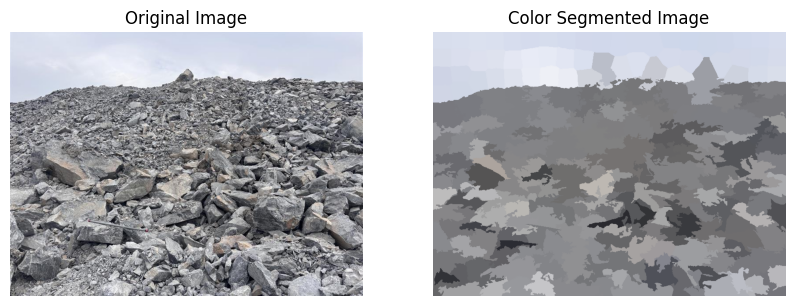

In [12]:
import cv2
import numpy as np
from skimage.segmentation import slic
from skimage.color import label2rgb
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/content/shared image (21).jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply SLIC segmentation
segments = slic(image, n_segments=300, compactness=10, sigma=1, start_label=1)

# Convert labels to random colors
segmented_image = label2rgb(segments, image, kind='avg')

# Show results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title("Color Segmented Image")
plt.axis('off')

plt.show()


In [13]:
# Step 1: Install packages (automatically handled)
!pip install torch torchvision torchaudio
!pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu118/torch2.0/index.html



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [2]:
# Installation commands for Google Colab (run these first)
!pip install segment-anything
!pip install opencv-python-headless pandas matplotlib seaborn pillow
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2025-08-11 17:02:07--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.35.37.123, 13.35.37.111, 13.35.37.90, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.35.37.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  23.5MB/s    in 4.4s    

2025-08-11 17:02:11 (81.7 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



✅ SAM is available
🤖 SAM ROCK FRAGMENT ANALYZER
Individual fragment detection using Meta's Segment Anything Model!
Based on SAM-Rock-Fragmentation repository approach

📤 Please upload your rock fragment image:


Saving shared image (22).jpg to shared image (22).jpg

📸 Analyzing: shared image (22).jpg

⚙️ Configuration:
• Model: SAM (Segment Anything Model) vit_b
• Approach: Individual fragment detection
• Calibration options available

📏 Calibration options:
1. Use default pixel_to_mm_ratio = 0.1
2. Provide reference object diameter (e.g., red ball)
✅ SAM initialized for rock fragment analysis

🚀 Processing steps:
1. Loading image...
📸 Image loaded: (2142, 2856, 3)
2. Detecting reference object (if any)...
⚠️ No reference object diameter provided, using default pixel_to_mm_ratio
3. Running SAM inference for individual fragments...
🤖 Running SAM inference for fragment detection...
This may take a few minutes depending on image size...
🎯 SAM detected 288 potential fragments
✅ Filtered to 288 valid fragments
4. Analyzing fragment properties...
📊 Analyzing individual fragments...
✅ Successfully analyzed 288 fragments
5. Creating colored fragment map...
🎨 Creating colored fragment map based on SAM 

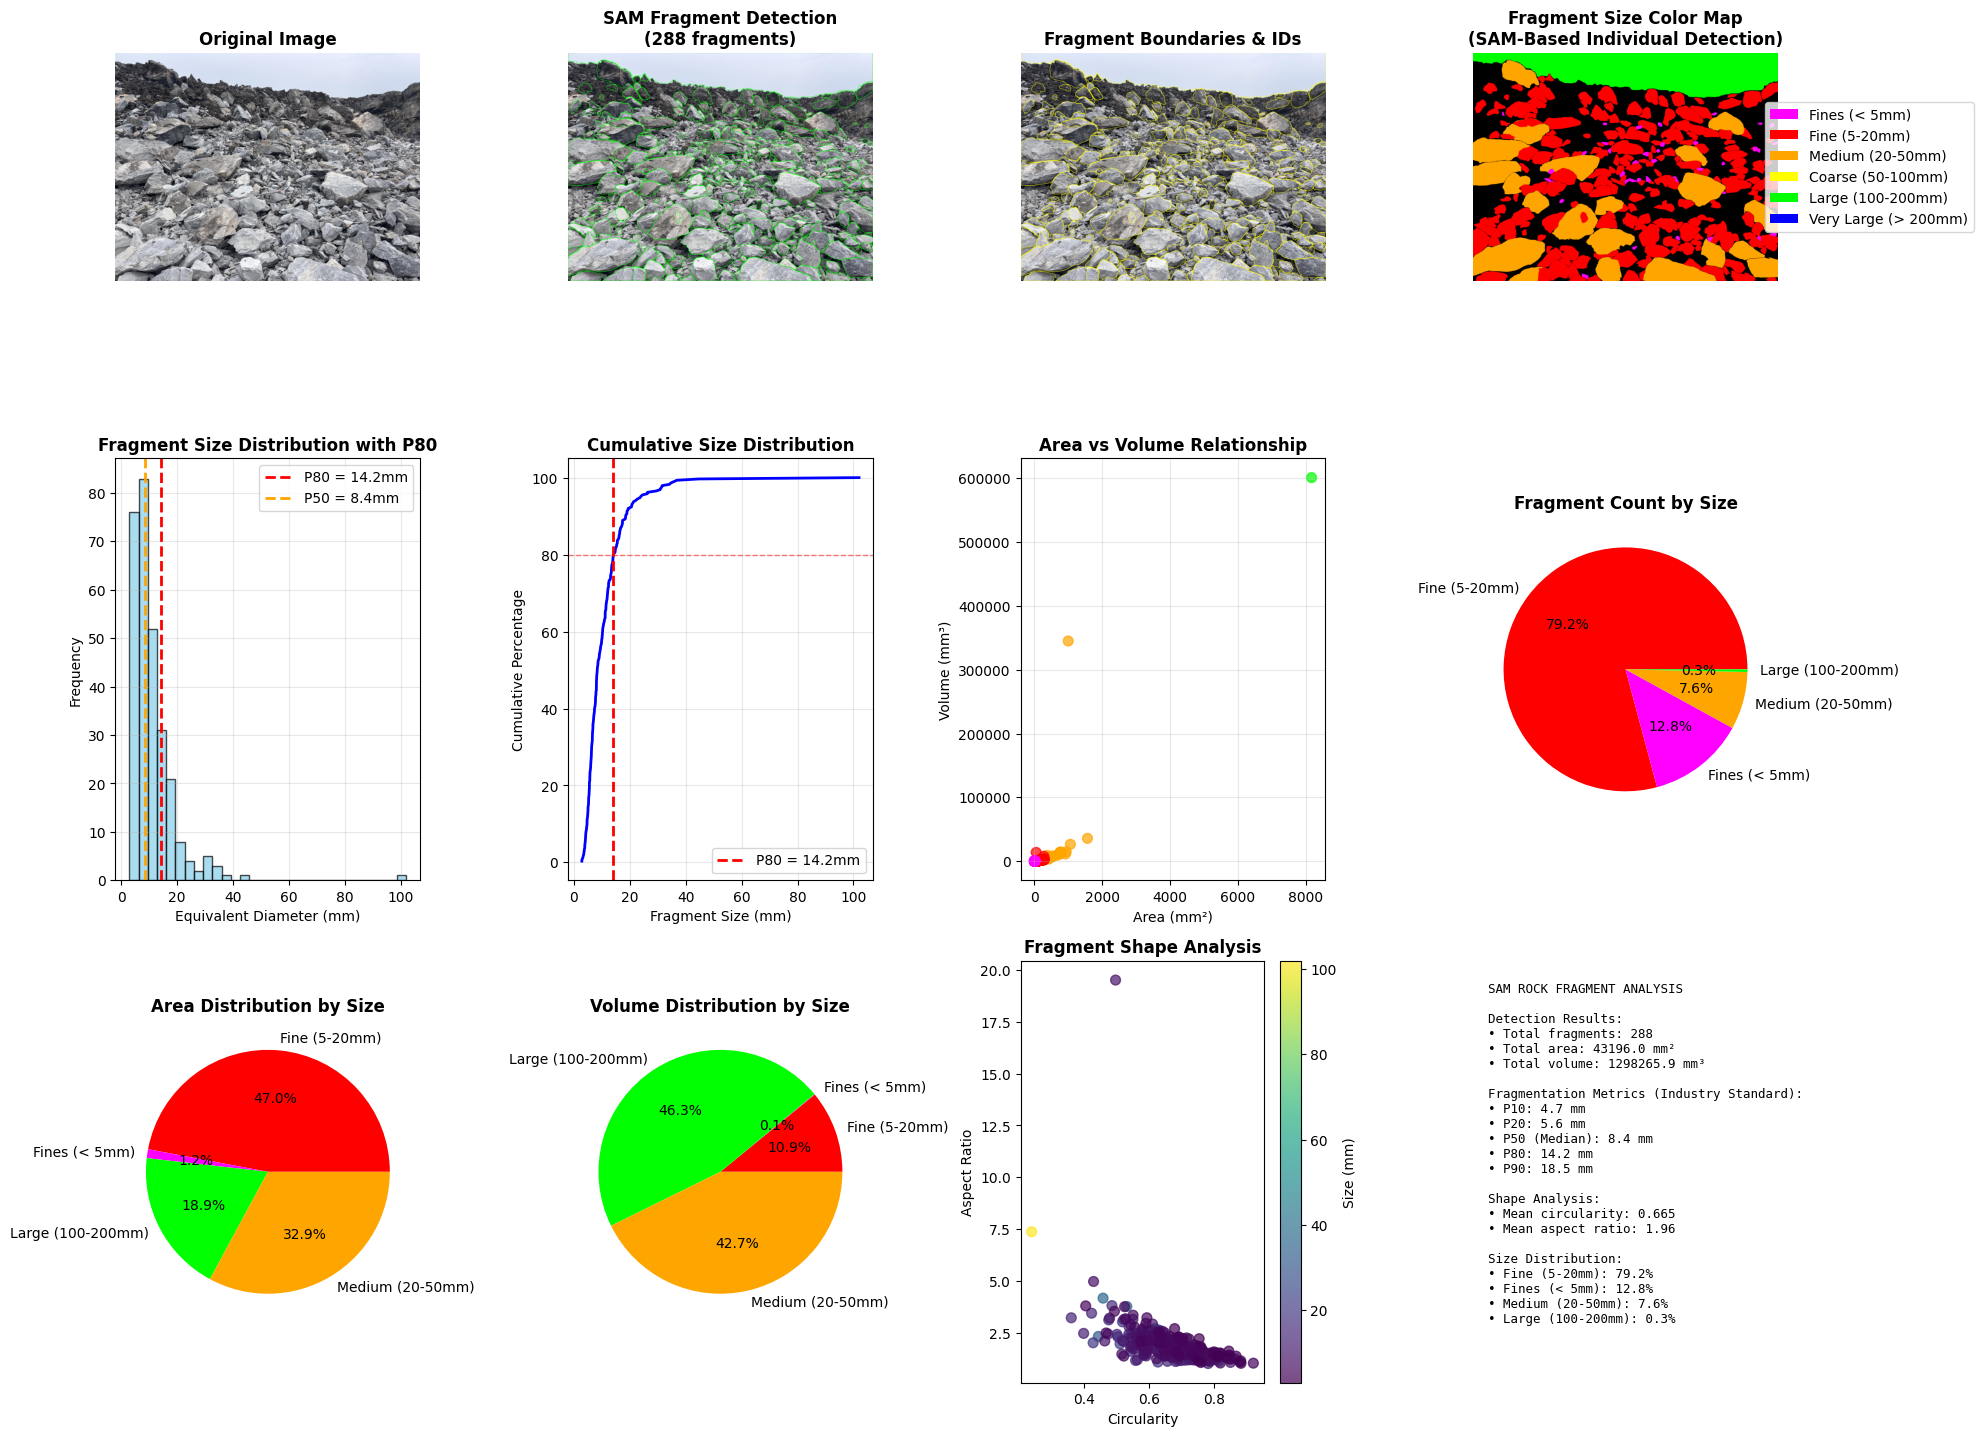


SAM-BASED ROCK FRAGMENT ANALYSIS RESULTS
🎯 Successfully detected 288 individual fragments using SAM
📏 Total area analyzed: 43196.0 mm²
📦 Total estimated volume: 1298265.9 mm³
📊 P80 (Key mining metric): 14.2 mm
📊 Median fragment size: 8.4 mm

📈 FRAGMENTATION DISTRIBUTION:
   Fine (5-20mm): 228 fragments (79.2%)
   Fines (< 5mm): 37 fragments (12.8%)
   Medium (20-50mm): 22 fragments (7.6%)
   Large (100-200mm): 1 fragments (0.3%)
7. Exporting results...

💾 Results exported:
   🎨 sam_fragment_analysis_colored_fragments.jpg
   🤖 sam_fragment_analysis_sam_detection.jpg
   🔍 sam_fragment_analysis_boundaries.jpg
   📊 sam_fragment_analysis_fragment_details.csv
   📈 sam_fragment_analysis_summary.csv
   📋 sam_fragment_analysis_size_distribution.csv

🎉 ANALYSIS COMPLETE!
✅ Individual fragments detected and analyzed using SAM
✅ Each fragment is precisely segmented and colored by size
✅ Industry-standard fragmentation metrics calculated (P80)
✅ Comprehensive analysis exported


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
import warnings
import urllib.request
import os
warnings.filterwarnings('ignore')

# SAM imports
try:
    from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
    SAM_AVAILABLE = True
    print("✅ SAM is available")
except ImportError:
    SAM_AVAILABLE = False
    print("❌ SAM not available, installing...")

class SAMRockFragmentAnalyzer:
    def __init__(self, image_path, pixel_to_mm_ratio=1.0, reference_object_diameter_mm=None):
        """
        SAM-based rock fragment analyzer for individual fragment detection.
        Based on the SAM-Rock-Fragmentation repository approach.

        Args:
            image_path: Path to the rock fragment image
            pixel_to_mm_ratio: Conversion factor from pixels to millimeters
            reference_object_diameter_mm: Diameter of reference object (e.g., red ball) in mm
        """
        self.image_path = image_path
        self.pixel_to_mm_ratio = pixel_to_mm_ratio
        self.reference_object_diameter_mm = reference_object_diameter_mm

        self.original_image = None
        self.sam_masks = []
        self.fragments = []
        self.colored_result = None
        self.mask_generator = None

        # Size categories with distinct colors (based on mining industry standards)
        self.size_categories = {
            'Fines (< 5mm)': {'color': [255, 0, 255], 'range': (0, 5)},         # Magenta
            'Fine (5-20mm)': {'color': [255, 0, 0], 'range': (5, 20)},          # Red
            'Medium (20-50mm)': {'color': [255, 165, 0], 'range': (20, 50)},    # Orange
            'Coarse (50-100mm)': {'color': [255, 255, 0], 'range': (50, 100)},  # Yellow
            'Large (100-200mm)': {'color': [0, 255, 0], 'range': (100, 200)},   # Green
            'Very Large (> 200mm)': {'color': [0, 0, 255], 'range': (200, 1000)} # Blue
        }

        self.setup_sam()

    def setup_sam(self):
        """Setup the Segment Anything Model."""
        if not SAM_AVAILABLE:
            raise ImportError("SAM is required. Please install it first.")

        # Download SAM model if not exists
        model_path = "sam_vit_b_01ec64.pth"
        if not os.path.exists(model_path):
            print("📥 Downloading SAM model (this may take a few minutes)...")
            urllib.request.urlretrieve(
                "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth",
                model_path
            )
            print("✅ SAM model downloaded")

        # Initialize SAM
        sam = sam_model_registry["vit_b"](checkpoint=model_path)

        # Configure mask generator for rock fragments
        self.mask_generator = SamAutomaticMaskGenerator(
            model=sam,
            points_per_side=32,           # More points for better fragment detection
            pred_iou_thresh=0.88,         # Higher threshold for better quality masks
            stability_score_thresh=0.95,  # Higher stability for rock fragments
            crop_n_layers=1,              # Crop layers for better detection
            crop_n_points_downscale_factor=2,
            min_mask_region_area=100,     # Minimum area for valid fragments
        )

        print("✅ SAM initialized for rock fragment analysis")

    def load_image(self):
        """Load and preprocess the image."""
        self.original_image = cv2.imread(self.image_path)
        if self.original_image is None:
            raise ValueError(f"Could not load image from {self.image_path}")

        # Convert BGR to RGB for SAM
        self.original_image = cv2.cvtColor(self.original_image, cv2.COLOR_BGR2RGB)

        print(f"📸 Image loaded: {self.original_image.shape}")
        return self.original_image

    def detect_reference_object(self):
        """
        Detect reference object (e.g., red ball) for scale calibration.
        This is based on the SAM-Rock-Fragmentation approach.
        """
        if self.reference_object_diameter_mm is None:
            print("⚠️ No reference object diameter provided, using default pixel_to_mm_ratio")
            return False

        # Convert to HSV for better color detection
        hsv = cv2.cvtColor(self.original_image, cv2.COLOR_RGB2HSV)

        # Define range for red color (adjust these values based on your reference object)
        lower_red1 = np.array([0, 120, 70])
        upper_red1 = np.array([10, 255, 255])
        lower_red2 = np.array([170, 120, 70])
        upper_red2 = np.array([180, 255, 255])

        # Create masks for red color
        mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
        red_mask = cv2.bitwise_or(mask1, mask2)

        # Find contours
        contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            # Find the largest circular contour (reference object)
            best_circle = None
            best_circularity = 0

            for contour in contours:
                area = cv2.contourArea(contour)
                if area > 100:  # Minimum area threshold
                    perimeter = cv2.arcLength(contour, True)
                    if perimeter > 0:
                        circularity = 4 * np.pi * area / (perimeter ** 2)

                        if circularity > best_circularity and circularity > 0.5:
                            best_circularity = circularity
                            best_circle = contour

            if best_circle is not None:
                # Calculate diameter in pixels
                (x, y), radius = cv2.minEnclosingCircle(best_circle)
                diameter_pixels = radius * 2

                # Calculate pixel to mm ratio
                self.pixel_to_mm_ratio = self.reference_object_diameter_mm / diameter_pixels

                print(f"✅ Reference object detected: {diameter_pixels:.1f} pixels = {self.reference_object_diameter_mm}mm")
                print(f"📏 Calibrated ratio: 1 pixel = {self.pixel_to_mm_ratio:.4f} mm")

                return True

        print("⚠️ Reference object not detected, using provided pixel_to_mm_ratio")
        return False

    def generate_sam_masks(self):
        """Generate masks using SAM for individual fragment detection."""
        if self.original_image is None:
            self.load_image()

        print("🤖 Running SAM inference for fragment detection...")
        print("This may take a few minutes depending on image size...")

        # Generate masks using SAM
        masks = self.mask_generator.generate(self.original_image)

        print(f"🎯 SAM detected {len(masks)} potential fragments")

        # Filter and sort masks by area (larger fragments first)
        filtered_masks = []
        for mask in masks:
            area = mask['area']
            if area > 100:  # Minimum area threshold
                filtered_masks.append(mask)

        # Sort by area (largest first)
        filtered_masks.sort(key=lambda x: x['area'], reverse=True)

        self.sam_masks = filtered_masks
        print(f"✅ Filtered to {len(self.sam_masks)} valid fragments")

        return self.sam_masks

    def analyze_sam_fragments(self):
        """Analyze each SAM-detected fragment and extract properties."""
        if not self.sam_masks:
            self.generate_sam_masks()

        self.fragments = []

        print("📊 Analyzing individual fragments...")

        for i, mask_data in enumerate(self.sam_masks):
            try:
                # Extract mask and properties
                mask = mask_data['segmentation']
                area_pixels = mask_data['area']
                bbox = mask_data['bbox']  # [x, y, width, height]

                # Calculate basic measurements
                area_mm2 = area_pixels * (self.pixel_to_mm_ratio ** 2)

                # Get contour for detailed analysis
                mask_uint8 = mask.astype(np.uint8) * 255
                contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                if not contours:
                    continue

                largest_contour = max(contours, key=cv2.contourArea)

                # Perimeter
                perimeter_pixels = cv2.arcLength(largest_contour, True)
                perimeter_mm = perimeter_pixels * self.pixel_to_mm_ratio

                # Fit ellipse for major/minor axes
                if len(largest_contour) >= 5:
                    ellipse = cv2.fitEllipse(largest_contour)
                    (center_x, center_y), (width, height), angle = ellipse
                    major_axis_mm = max(width, height) * self.pixel_to_mm_ratio
                    minor_axis_mm = min(width, height) * self.pixel_to_mm_ratio
                else:
                    # Fallback to bounding box
                    x, y, w, h = bbox
                    major_axis_mm = max(w, h) * self.pixel_to_mm_ratio
                    minor_axis_mm = min(w, h) * self.pixel_to_mm_ratio

                # Shape properties
                if perimeter_pixels > 0:
                    circularity = 4 * np.pi * area_pixels / (perimeter_pixels ** 2)
                else:
                    circularity = 0

                aspect_ratio = major_axis_mm / minor_axis_mm if minor_axis_mm > 0 else 1
                equivalent_diameter_mm = 2 * np.sqrt(area_mm2 / np.pi)

                # Volume estimation (multiple methods for accuracy)
                # Method 1: Ellipsoid (best for rounded fragments)
                a = major_axis_mm / 2
                b = minor_axis_mm / 2
                c = equivalent_diameter_mm / 4  # Estimated thickness
                volume_ellipsoid = (4/3) * np.pi * a * b * c

                # Method 2: Rectangular prism (for angular fragments)
                thickness = equivalent_diameter_mm * 0.4  # Conservative thickness
                volume_prism = major_axis_mm * minor_axis_mm * thickness

                # Method 3: Cylinder (intermediate approach)
                radius = equivalent_diameter_mm / 2
                height = major_axis_mm * 0.3
                volume_cylinder = np.pi * (radius ** 2) * height

                # Weighted average based on circularity
                if circularity > 0.7:
                    # More circular -> more like ellipsoid
                    estimated_volume = volume_ellipsoid * 0.6 + volume_cylinder * 0.4
                else:
                    # More angular -> more like prism
                    estimated_volume = volume_prism * 0.5 + volume_cylinder * 0.5

                # Centroid
                M = cv2.moments(largest_contour)
                if M["m00"] != 0:
                    centroid_x = M["m10"] / M["m00"]
                    centroid_y = M["m01"] / M["m00"]
                else:
                    centroid_x, centroid_y = bbox[0] + bbox[2]/2, bbox[1] + bbox[3]/2

                fragment = {
                    'id': i,
                    'area_pixels': area_pixels,
                    'area_mm2': area_mm2,
                    'perimeter_pixels': perimeter_pixels,
                    'perimeter_mm': perimeter_mm,
                    'major_axis_mm': major_axis_mm,
                    'minor_axis_mm': minor_axis_mm,
                    'equivalent_diameter_mm': equivalent_diameter_mm,
                    'circularity': circularity,
                    'aspect_ratio': aspect_ratio,
                    'estimated_volume_mm3': estimated_volume,
                    'volume_ellipsoid_mm3': volume_ellipsoid,
                    'volume_prism_mm3': volume_prism,
                    'volume_cylinder_mm3': volume_cylinder,
                    'centroid': (centroid_x, centroid_y),
                    'bbox': bbox,
                    'mask': mask,
                    'stability_score': mask_data.get('stability_score', 0),
                    'predicted_iou': mask_data.get('predicted_iou', 0)
                }

                self.fragments.append(fragment)

            except Exception as e:
                print(f"⚠️ Error analyzing fragment {i}: {e}")
                continue

        print(f"✅ Successfully analyzed {len(self.fragments)} fragments")
        return self.fragments

    def categorize_fragment_size(self, equivalent_diameter_mm):
        """Categorize fragment based on equivalent diameter (industry standard)."""
        for category, info in self.size_categories.items():
            min_size, max_size = info['range']
            if min_size <= equivalent_diameter_mm < max_size:
                return category
        return 'Very Large (> 200mm)'

    def create_colored_fragment_map(self):
        """Create colored map with each SAM fragment colored by size."""
        if not self.fragments:
            print("⚠️ No fragments to color")
            return None

        height, width = self.original_image.shape[:2]
        colored_map = np.zeros((height, width, 3), dtype=np.uint8)

        print("🎨 Creating colored fragment map based on SAM detection...")

        for fragment in self.fragments:
            mask = fragment['mask']
            equivalent_diameter_mm = fragment['equivalent_diameter_mm']

            # Get size category and color
            size_category = self.categorize_fragment_size(equivalent_diameter_mm)
            color = self.size_categories[size_category]['color']

            # Apply color to fragment
            colored_map[mask] = color

        self.colored_result = colored_map
        return colored_map

    def calculate_fragmentation_statistics(self):
        """Calculate comprehensive fragmentation statistics including P80."""
        if not self.fragments:
            return None

        df = pd.DataFrame(self.fragments)
        df['size_category'] = df['equivalent_diameter_mm'].apply(self.categorize_fragment_size)

        # Sort by equivalent diameter for percentile calculations
        sizes = sorted(df['equivalent_diameter_mm'].tolist())

        # Calculate key fragmentation metrics
        total_fragments = len(self.fragments)
        total_area = df['area_mm2'].sum()
        total_volume = df['estimated_volume_mm3'].sum()

        # Percentile calculations (industry standard)
        p10 = np.percentile(sizes, 10)
        p20 = np.percentile(sizes, 20)
        p50 = np.percentile(sizes, 50)  # Median
        p80 = np.percentile(sizes, 80)  # Key metric in mining
        p90 = np.percentile(sizes, 90)

        # Size distribution
        size_counts = df['size_category'].value_counts()
        size_percentages = (size_counts / total_fragments * 100).round(2)

        # Area and volume distributions
        area_by_size = df.groupby('size_category')['area_mm2'].sum()
        area_percentages = (area_by_size / total_area * 100).round(2)

        volume_by_size = df.groupby('size_category')['estimated_volume_mm3'].sum()
        volume_percentages = (volume_by_size / total_volume * 100).round(2)

        statistics = {
            'total_fragments': total_fragments,
            'total_area_mm2': total_area,
            'total_volume_mm3': total_volume,
            'mean_fragment_size_mm': df['equivalent_diameter_mm'].mean(),
            'median_fragment_size_mm': p50,
            'std_fragment_size_mm': df['equivalent_diameter_mm'].std(),
            'p10_mm': p10,
            'p20_mm': p20,
            'p50_mm': p50,
            'p80_mm': p80,  # Key metric
            'p90_mm': p90,
            'mean_circularity': df['circularity'].mean(),
            'mean_aspect_ratio': df['aspect_ratio'].mean(),
            'size_distribution_counts': size_counts.to_dict(),
            'size_distribution_percentages': size_percentages.to_dict(),
            'area_distribution_percentages': area_percentages.to_dict(),
            'volume_distribution_percentages': volume_percentages.to_dict(),
        }

        return statistics, df

    def visualize_comprehensive_results(self):
        """Create comprehensive visualizations including P80 analysis."""
        if not self.fragments:
            print("⚠️ No fragments to visualize")
            return

        stats, df = self.calculate_fragmentation_statistics()

        if self.colored_result is None:
            self.create_colored_fragment_map()

        # Create comprehensive visualization
        fig, axes = plt.subplots(3, 4, figsize=(20, 15))

        # 1. Original image
        axes[0, 0].imshow(self.original_image)
        axes[0, 0].set_title('Original Image', fontweight='bold', fontsize=12)
        axes[0, 0].axis('off')

        # 2. SAM detection overlay
        sam_overlay = self.create_sam_overlay()
        axes[0, 1].imshow(sam_overlay)
        axes[0, 1].set_title(f'SAM Fragment Detection\n({len(self.fragments)} fragments)',
                           fontweight='bold', fontsize=12)
        axes[0, 1].axis('off')

        # 3. Fragment boundaries with IDs
        boundary_img = self.create_boundary_visualization()
        axes[0, 2].imshow(boundary_img)
        axes[0, 2].set_title('Fragment Boundaries & IDs', fontweight='bold', fontsize=12)
        axes[0, 2].axis('off')

        # 4. MAIN RESULT: Colored size map
        axes[0, 3].imshow(self.colored_result)
        axes[0, 3].set_title('Fragment Size Color Map\n(SAM-Based Individual Detection)',
                           fontweight='bold', fontsize=12)
        axes[0, 3].axis('off')

        # Add legend
        legend_elements = []
        for category, info in self.size_categories.items():
            color = np.array(info['color']) / 255
            legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, label=category))
        axes[0, 3].legend(handles=legend_elements, loc='center', bbox_to_anchor=(1.3, 0.5))

        # 5. Fragment size distribution with P80
        axes[1, 0].hist(df['equivalent_diameter_mm'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1, 0].axvline(stats['p80_mm'], color='red', linestyle='--', linewidth=2, label=f'P80 = {stats["p80_mm"]:.1f}mm')
        axes[1, 0].axvline(stats['p50_mm'], color='orange', linestyle='--', linewidth=2, label=f'P50 = {stats["p50_mm"]:.1f}mm')
        axes[1, 0].set_xlabel('Equivalent Diameter (mm)')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Fragment Size Distribution with P80', fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # 6. Cumulative size distribution
        sorted_sizes = np.sort(df['equivalent_diameter_mm'])
        cumulative = np.arange(1, len(sorted_sizes) + 1) / len(sorted_sizes) * 100
        axes[1, 1].plot(sorted_sizes, cumulative, 'b-', linewidth=2)
        axes[1, 1].axvline(stats['p80_mm'], color='red', linestyle='--', linewidth=2, label=f'P80 = {stats["p80_mm"]:.1f}mm')
        axes[1, 1].axhline(80, color='red', linestyle='--', linewidth=1, alpha=0.5)
        axes[1, 1].set_xlabel('Fragment Size (mm)')
        axes[1, 1].set_ylabel('Cumulative Percentage')
        axes[1, 1].set_title('Cumulative Size Distribution', fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        # 7. Area vs Volume scatter
        scatter_colors = [self.size_categories[cat]['color'] for cat in df['size_category']]
        axes[1, 2].scatter(df['area_mm2'], df['estimated_volume_mm3'],
                          c=np.array(scatter_colors)/255, alpha=0.7, s=50)
        axes[1, 2].set_xlabel('Area (mm²)')
        axes[1, 2].set_ylabel('Volume (mm³)')
        axes[1, 2].set_title('Area vs Volume Relationship', fontweight='bold')
        axes[1, 2].grid(True, alpha=0.3)

        # 8. Size category pie chart
        categories = list(stats['size_distribution_counts'].keys())
        counts = list(stats['size_distribution_counts'].values())
        colors_pie = [np.array(self.size_categories[cat]['color'])/255 for cat in categories]

        axes[1, 3].pie(counts, labels=categories, autopct='%1.1f%%', colors=colors_pie)
        axes[1, 3].set_title('Fragment Count by Size', fontweight='bold')

        # 9. Area distribution
        area_cats = list(stats['area_distribution_percentages'].keys())
        area_percs = list(stats['area_distribution_percentages'].values())
        area_colors = [np.array(self.size_categories[cat]['color'])/255 for cat in area_cats]

        axes[2, 0].pie(area_percs, labels=area_cats, autopct='%1.1f%%', colors=area_colors)
        axes[2, 0].set_title('Area Distribution by Size', fontweight='bold')

        # 10. Volume distribution
        vol_cats = list(stats['volume_distribution_percentages'].keys())
        vol_percs = list(stats['volume_distribution_percentages'].values())
        vol_colors = [np.array(self.size_categories[cat]['color'])/255 for cat in vol_cats]

        axes[2, 1].pie(vol_percs, labels=vol_cats, autopct='%1.1f%%', colors=vol_colors)
        axes[2, 1].set_title('Volume Distribution by Size', fontweight='bold')

        # 11. Fragment quality metrics
        axes[2, 2].scatter(df['circularity'], df['aspect_ratio'],
                          c=df['equivalent_diameter_mm'], cmap='viridis', alpha=0.7, s=50)
        axes[2, 2].set_xlabel('Circularity')
        axes[2, 2].set_ylabel('Aspect Ratio')
        axes[2, 2].set_title('Fragment Shape Analysis', fontweight='bold')
        cbar = plt.colorbar(axes[2, 2].collections[0], ax=axes[2, 2])
        cbar.set_label('Size (mm)')

        # 12. Statistics summary
        axes[2, 3].axis('off')
        stats_text = f"""SAM ROCK FRAGMENT ANALYSIS

Detection Results:
• Total fragments: {stats['total_fragments']}
• Total area: {stats['total_area_mm2']:.1f} mm²
• Total volume: {stats['total_volume_mm3']:.1f} mm³

Fragmentation Metrics (Industry Standard):
• P10: {stats['p10_mm']:.1f} mm
• P20: {stats['p20_mm']:.1f} mm
• P50 (Median): {stats['p50_mm']:.1f} mm
• P80: {stats['p80_mm']:.1f} mm
• P90: {stats['p90_mm']:.1f} mm

Shape Analysis:
• Mean circularity: {stats['mean_circularity']:.3f}
• Mean aspect ratio: {stats['mean_aspect_ratio']:.2f}

Size Distribution:"""

        for category, percentage in stats['size_distribution_percentages'].items():
            stats_text += f"\n• {category}: {percentage:.1f}%"

        axes[2, 3].text(0.05, 0.95, stats_text, transform=axes[2, 3].transAxes,
                       fontsize=9, verticalalignment='top', fontfamily='monospace')

        plt.tight_layout()
        plt.show()

        # Print detailed summary
        print("\n" + "="*80)
        print("SAM-BASED ROCK FRAGMENT ANALYSIS RESULTS")
        print("="*80)
        print(f"🎯 Successfully detected {stats['total_fragments']} individual fragments using SAM")
        print(f"📏 Total area analyzed: {stats['total_area_mm2']:.1f} mm²")
        print(f"📦 Total estimated volume: {stats['total_volume_mm3']:.1f} mm³")
        print(f"📊 P80 (Key mining metric): {stats['p80_mm']:.1f} mm")
        print(f"📊 Median fragment size: {stats['p50_mm']:.1f} mm")

        print(f"\n📈 FRAGMENTATION DISTRIBUTION:")
        for category, percentage in stats['size_distribution_percentages'].items():
            count = stats['size_distribution_counts'][category]
            print(f"   {category}: {count} fragments ({percentage:.1f}%)")

    def create_sam_overlay(self):
        """Create overlay showing SAM detection boundaries."""
        overlay = self.original_image.copy()

        for fragment in self.fragments:
            mask = fragment['mask']

            # Find contour
            mask_uint8 = mask.astype(np.uint8) * 255
            contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if contours:
                # Draw contour
                cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)

        return overlay

    def create_boundary_visualization(self):
        """Create visualization with fragment boundaries and IDs."""
        img_with_boundaries = self.original_image.copy()

        for fragment in self.fragments:
            mask = fragment['mask']
            fragment_id = fragment['id']
            centroid = fragment['centroid']

            # Find contour
            mask_uint8 = mask.astype(np.uint8) * 255
            contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if contours:
                # Draw contour
                cv2.drawContours(img_with_boundaries, contours, -1, (255, 255, 0), 2)

                # Add fragment ID
                cv2.putText(img_with_boundaries, str(fragment_id),
                           (int(centroid[0])-10, int(centroid[1])+5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        return img_with_boundaries

    def export_results(self, output_prefix='sam_fragment_analysis'):
        """Export comprehensive SAM-based analysis results."""
        if not self.fragments:
            print("⚠️ No results to export")
            return

        # Export colored result
        if self.colored_result is not None:
            colored_bgr = cv2.cvtColor(self.colored_result, cv2.COLOR_RGB2BGR)
            cv2.imwrite(f'{output_prefix}_colored_fragments.jpg', colored_bgr)

        # Export SAM overlay
        sam_overlay = self.create_sam_overlay()
        sam_bgr = cv2.cvtColor(sam_overlay, cv2.COLOR_RGB2BGR)
        cv2.imwrite(f'{output_prefix}_sam_detection.jpg', sam_bgr)

        # Export boundaries
        boundary_img = self.create_boundary_visualization()
        boundary_bgr = cv2.cvtColor(boundary_img, cv2.COLOR_RGB2BGR)
        cv2.imwrite(f'{output_prefix}_boundaries.jpg', boundary_bgr)

        # Export detailed fragment data
        df = pd.DataFrame(self.fragments)
        df['size_category'] = df['equivalent_diameter_mm'].apply(self.categorize_fragment_size)

        # Remove mask for CSV export
        export_df = df.drop('mask', axis=1)
        export_df.to_csv(f'{output_prefix}_fragment_details.csv', index=False)

        # Export fragmentation statistics
        stats, _ = self.calculate_fragmentation_statistics()

        # Create comprehensive summary
        summary_data = []
        summary_data.append(['Metric', 'Value'])
        summary_data.append(['Total Fragments', stats['total_fragments']])
        summary_data.append(['Total Area (mm²)', f"{stats['total_area_mm2']:.1f}"])
        summary_data.append(['Total Volume (mm³)', f"{stats['total_volume_mm3']:.1f}"])
        summary_data.append(['P10 (mm)', f"{stats['p10_mm']:.1f}"])
        summary_data.append(['P20 (mm)', f"{stats['p20_mm']:.1f}"])
        summary_data.append(['P50 Median (mm)', f"{stats['p50_mm']:.1f}"])
        summary_data.append(['P80 (mm)', f"{stats['p80_mm']:.1f}"])
        summary_data.append(['P90 (mm)', f"{stats['p90_mm']:.1f}"])
        summary_data.append(['Mean Circularity', f"{stats['mean_circularity']:.3f}"])
        summary_data.append(['Mean Aspect Ratio', f"{stats['mean_aspect_ratio']:.2f}"])

        summary_df = pd.DataFrame(summary_data[1:], columns=summary_data[0])
        summary_df.to_csv(f'{output_prefix}_summary.csv', index=False)

        # Export size distribution
        size_dist_data = []
        for category in self.size_categories.keys():
            count = stats['size_distribution_counts'].get(category, 0)
            count_pct = stats['size_distribution_percentages'].get(category, 0)
            area_pct = stats['area_distribution_percentages'].get(category, 0)
            vol_pct = stats['volume_distribution_percentages'].get(category, 0)

            size_dist_data.append([category, count, count_pct, area_pct, vol_pct])

        size_dist_df = pd.DataFrame(size_dist_data, columns=[
            'Size_Category', 'Fragment_Count', 'Count_Percentage',
            'Area_Percentage', 'Volume_Percentage'
        ])
        size_dist_df.to_csv(f'{output_prefix}_size_distribution.csv', index=False)

        print(f"\n💾 Results exported:")
        print(f"   🎨 {output_prefix}_colored_fragments.jpg")
        print(f"   🤖 {output_prefix}_sam_detection.jpg")
        print(f"   🔍 {output_prefix}_boundaries.jpg")
        print(f"   📊 {output_prefix}_fragment_details.csv")
        print(f"   📈 {output_prefix}_summary.csv")
        print(f"   📋 {output_prefix}_size_distribution.csv")

def install_sam():
    """Install SAM and dependencies in Google Colab."""
    import subprocess
    import sys

    print("🔧 Installing SAM and dependencies...")

    # Install required packages
    packages = [
        "segment-anything",
        "opencv-python-headless",
        "pandas",
        "matplotlib",
        "seaborn",
        "pillow"
    ]

    for package in packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

    print("✅ SAM installation complete!")

def main_colab():
    """Main function for Google Colab with SAM-based fragment analysis."""
    from google.colab import files

    print("🤖 SAM ROCK FRAGMENT ANALYZER")
    print("="*50)
    print("Individual fragment detection using Meta's Segment Anything Model!")
    print("Based on SAM-Rock-Fragmentation repository approach")

    # Check and install SAM if needed
    if not SAM_AVAILABLE:
        print("📦 Installing required packages...")
        install_sam()

        # Re-import after installation
        global sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
        from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

    # Upload image
    print("\n📤 Please upload your rock fragment image:")
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]
    print(f"\n📸 Analyzing: {filename}")

    # Configuration
    print("\n⚙️ Configuration:")
    print("• Model: SAM (Segment Anything Model) vit_b")
    print("• Approach: Individual fragment detection")
    print("• Calibration options available")

    # Ask for calibration
    print("\n📏 Calibration options:")
    print("1. Use default pixel_to_mm_ratio = 0.1")
    print("2. Provide reference object diameter (e.g., red ball)")

    try:
        # Initialize analyzer
        analyzer = SAMRockFragmentAnalyzer(
            filename,
            pixel_to_mm_ratio=0.1,
            reference_object_diameter_mm=None  # Can be set if reference object is present
        )

        print("\n🚀 Processing steps:")
        print("1. Loading image...")
        analyzer.load_image()

        print("2. Detecting reference object (if any)...")
        analyzer.detect_reference_object()

        print("3. Running SAM inference for individual fragments...")
        analyzer.generate_sam_masks()

        if analyzer.sam_masks:
            print("4. Analyzing fragment properties...")
            analyzer.analyze_sam_fragments()

            if analyzer.fragments:
                print("5. Creating colored fragment map...")
                analyzer.create_colored_fragment_map()

                print("6. Generating comprehensive visualizations...")
                analyzer.visualize_comprehensive_results()

                print("7. Exporting results...")
                analyzer.export_results()

                print("\n🎉 ANALYSIS COMPLETE!")
                print("✅ Individual fragments detected and analyzed using SAM")
                print("✅ Each fragment is precisely segmented and colored by size")
                print("✅ Industry-standard fragmentation metrics calculated (P80)")
                print("✅ Comprehensive analysis exported")

            else:
                print("❌ No valid fragments found after analysis")
        else:
            print("❌ SAM did not detect any fragments. Try:")
            print("   • Using a higher resolution image")
            print("   • Ensuring good image contrast")
            print("   • Checking if the image contains distinct rock fragments")

        return analyzer

    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()

        print("\n🔧 Troubleshooting:")
        print("1. Ensure proper image format (JPG, PNG)")
        print("2. Check internet connection for model download")
        print("3. Verify image contains distinct rock fragments")
        print("4. Try using a GPU runtime for faster processing")

        return None

# For Google Colab, run this:
analyzer = main_colab()